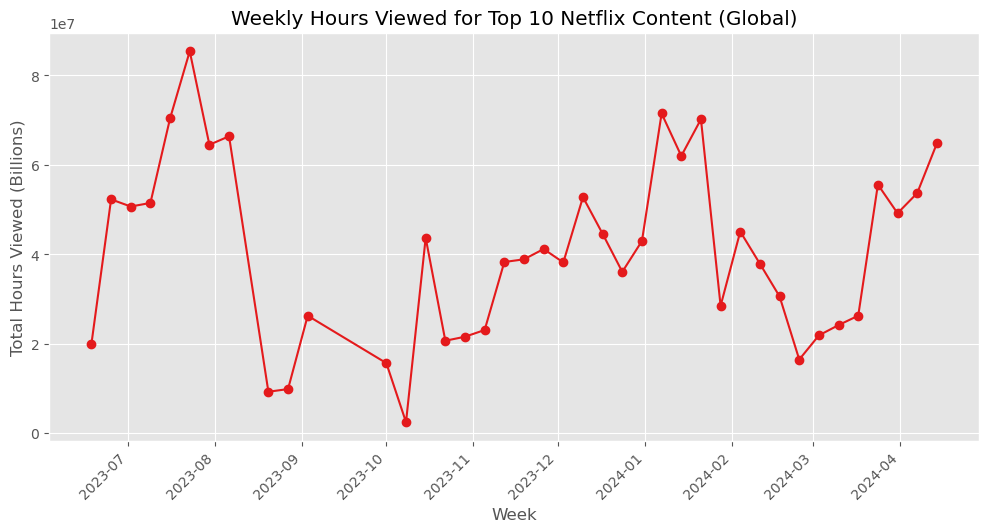

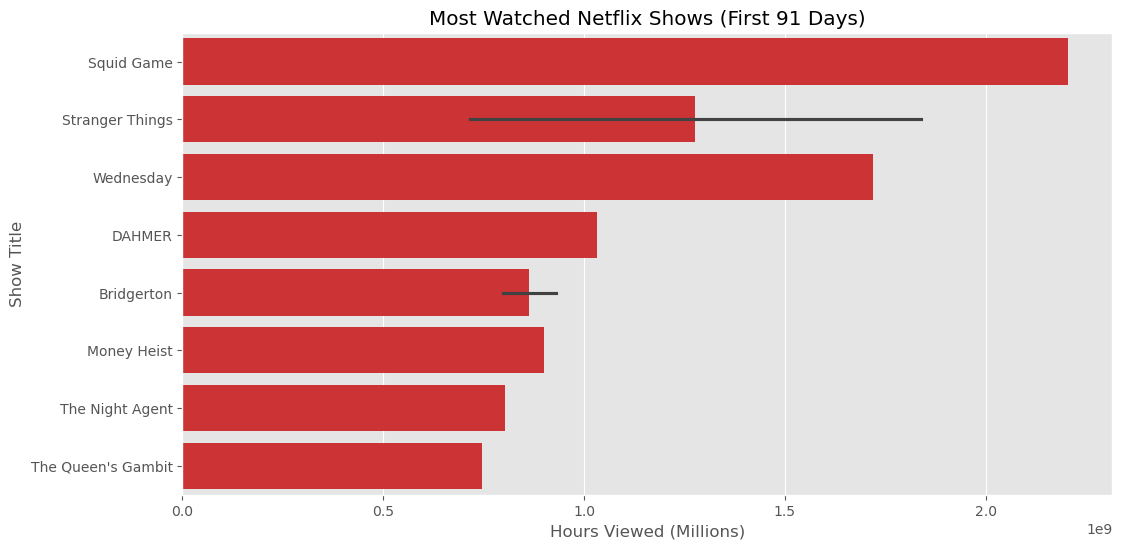

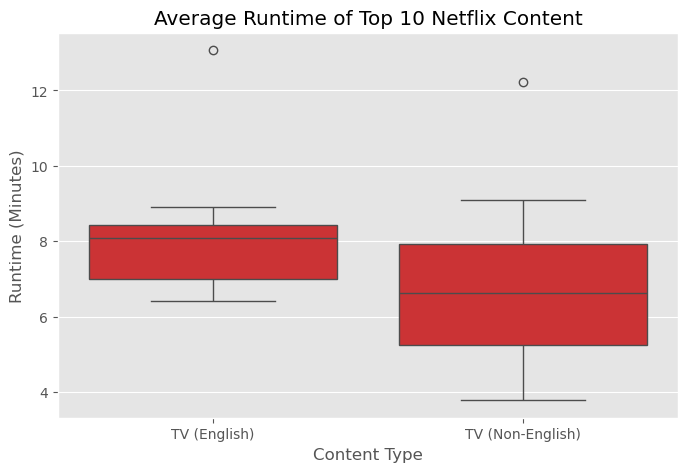

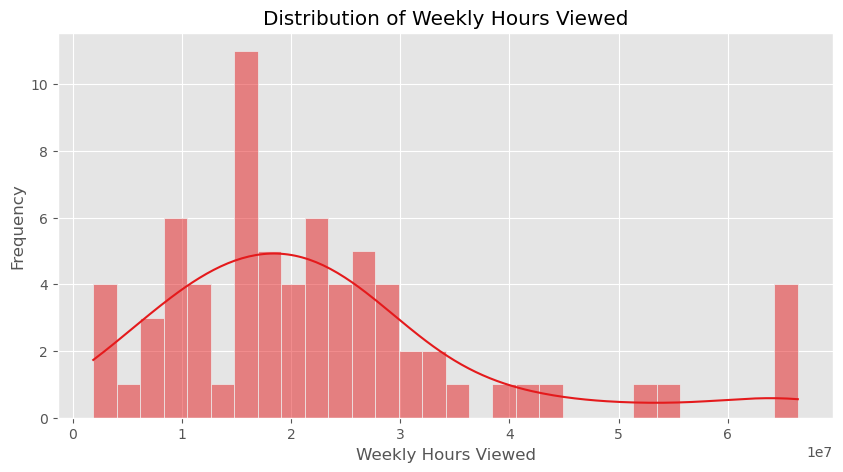

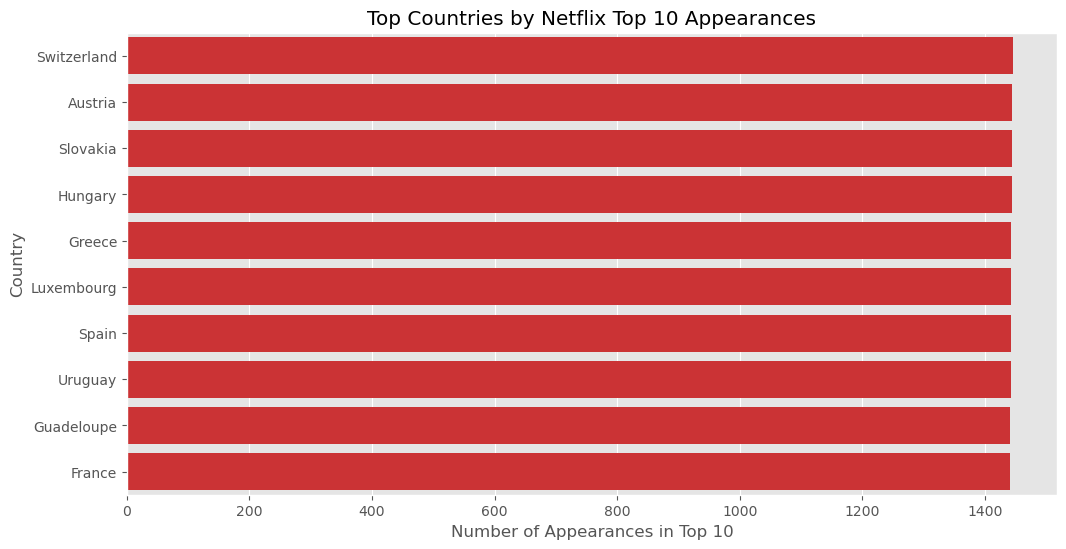

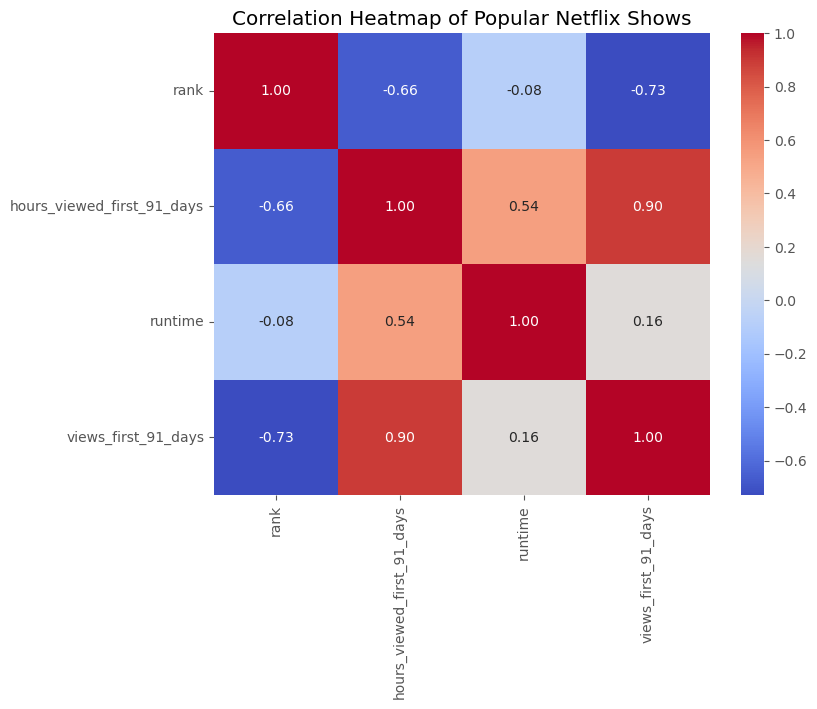

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os


# load datasets 
global_file = "all-weeks-global-netflix.xlsx"
popular_file = "most-popular-netflix.xlsx"
countries_file = "all-weeks-countries-netflix.xlsx"

# Check and loaded datasets
files = {
    "global_top10": global_file,
    "most_popular": popular_file,
    "country_top10": countries_file
}

datasets = {}

for key, path in files.items():
    if os.path.exists(path):
        datasets[key] = pd.read_excel(path)
    else:
        print(f"Warning: File not found - {path}")

# Ensure datasets exist before proceeding
if "global_top10" not in datasets or "most_popular" not in datasets:
    raise SystemExit("Critical data missing. Please check the files and try again.")

global_top10 = datasets.get("global_top10", pd.DataFrame())
most_popular = datasets.get("most_popular", pd.DataFrame())
country_top10 = datasets.get("country_top10", pd.DataFrame())  # Optional

# Ensure necessary columns exist
required_columns = {
    "global_top10": ["week", "weekly_hours_viewed"],
    "most_popular": ["show_title", "hours_viewed_first_91_days", "category", "runtime"],
    "country_top10": ["week", "country_name"]
}

def check_columns(df, name):
    missing = [col for col in required_columns.get(name, []) if col not in df.columns]
    if missing:
        print(f"Warning: Missing columns in {name}: {missing}")

check_columns(global_top10, "global_top10")
check_columns(most_popular, "most_popular")
check_columns(country_top10, "country_top10")

# Data Cleaning & Transformation
global_top10["week"] = pd.to_datetime(global_top10["week"], errors="coerce")
country_top10["week"] = pd.to_datetime(country_top10["week"], errors="coerce")

# Ensure numeric values
global_top10["weekly_hours_viewed"] = pd.to_numeric(global_top10["weekly_hours_viewed"], errors="coerce")
most_popular["hours_viewed_first_91_days"] = pd.to_numeric(most_popular["hours_viewed_first_91_days"], errors="coerce")
most_popular["runtime"] = pd.to_numeric(most_popular["runtime"], errors="coerce")

# Handling missing values
global_top10.dropna(inplace=True)
most_popular.dropna(inplace=True)
country_top10.dropna(inplace=True)

# Analysis & Visualizations
plt.style.use("ggplot")
sns.set_palette("Set1")

# 1. Trend of Weekly Hours Viewed Over Time
plt.figure(figsize=(12, 6))
global_top10.groupby("week")["weekly_hours_viewed"].sum().plot(marker="o")
plt.title("Weekly Hours Viewed for Top 10 Netflix Content (Global)")
plt.xlabel("Week")
plt.ylabel("Total Hours Viewed (Billions)")
plt.xticks(rotation=45)
plt.show()

# 2. Most Watched Shows in First 91 Days
plt.figure(figsize=(12, 6))
top_10_popular = most_popular.nlargest(10, "hours_viewed_first_91_days")
sns.barplot(
    x="hours_viewed_first_91_days", 
    y="show_title", 
    data=top_10_popular, 
    order=top_10_popular.sort_values("hours_viewed_first_91_days", ascending=False)["show_title"]
)
plt.title("Most Watched Netflix Shows (First 91 Days)")
plt.xlabel("Hours Viewed (Millions)")
plt.ylabel("Show Title")
plt.show()

# 3. Average Duration of Top 10 Content (Movies vs. TV Shows)
plt.figure(figsize=(8, 5))
sns.boxplot(x="category", y="runtime", data=most_popular)
plt.title("Average Runtime of Top 10 Netflix Content")
plt.xlabel("Content Type")
plt.ylabel("Runtime (Minutes)")
plt.show()

# 4. Distribution of Weekly Hours Viewed
plt.figure(figsize=(10, 5))
sns.histplot(global_top10["weekly_hours_viewed"], bins=30, kde=True)
plt.title("Distribution of Weekly Hours Viewed")
plt.xlabel("Weekly Hours Viewed")
plt.ylabel("Frequency")
plt.show()

# 5. Top Countries by Content Popularity
if "country_name" in country_top10.columns:
    plt.figure(figsize=(12, 6))
    top_countries = country_top10["country_name"].value_counts().nlargest(10)
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title("Top Countries by Netflix Top 10 Appearances")
    plt.xlabel("Number of Appearances in Top 10")
    plt.ylabel("Country")
    plt.show()
else:
    print("Warning: 'country_name' column not found in country_top10 dataset. Skipping visualization.")

# 6. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(most_popular.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Popular Netflix Shows")
plt.show()


